# `LeaveBallOut`

`LeaveBallOut` is a **buffered leave-one-out** cross-validator.  For each test
point *i* it excludes all training candidates within a buffer of radius *r*,
then trains on every point outside that buffer.

This guards against **spatial leakage**: nearby points share spatial structure
(autocorrelation, measurement artefacts), so including them in training inflates
apparent skill.  The buffer removes the 'neighbourhood effect' so that the
model must generalise across space to predict *i*.


In [1]:
import numpy
import geopandas
import geodatasets
import colormaps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from spml.validation import LeaveBallOut

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Small example — Chicago community areas

We start with Chicago's 77 community areas (UTM 16N, metres).
The small n makes the exclusion mechanism easy to visualise.


In [2]:
chicago = geopandas.read_file(geodatasets.get_path('geoda.chicago_health')).to_crs('EPSG:32616')
chicago['income'] = chicago['PerCInc14'].fillna(chicago['PerCInc14'].median())
coords_chi = numpy.column_stack([
    chicago.geometry.centroid.x,
    chicago.geometry.centroid.y,
])
print(f'n = {len(chicago)} community areas')

n = 77 community areas


### The exclusion buffer

For a single test point the diagram below shows which observations fall
inside the 5 km exclusion buffer (excluded from training — grey) and which
remain as valid training points (blue).


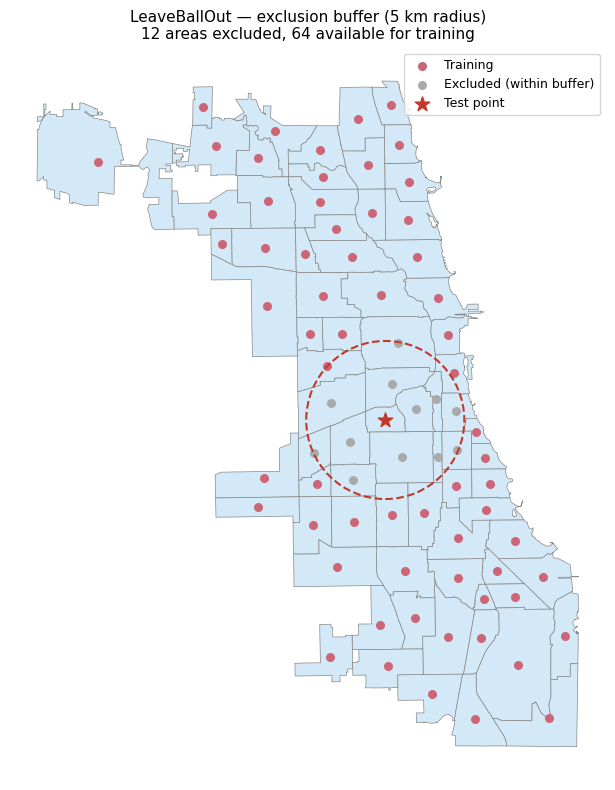

Excluded: 12 areas   Training: 64 areas


In [3]:
RADIUS_CHI = 5_000   # 5 km

# Pick a central community area as the demo test point
cx_all = chicago.geometry.centroid.x
cy_all = chicago.geometry.centroid.y
center_x = float(cx_all.mean())
center_y = float(cy_all.mean())
dists_to_center = numpy.hypot(cx_all - center_x, cy_all - center_y)
focal_idx = int(dists_to_center.idxmin())

focal_xy = coords_chi[focal_idx]
dists_from_focal = numpy.linalg.norm(coords_chi - focal_xy, axis=1)
in_buffer = (dists_from_focal <= RADIUS_CHI) & (numpy.arange(len(chicago)) != focal_idx)

fig, ax = plt.subplots(figsize=(7, 8))
chicago.plot(ax=ax, color='#d4e9f7', edgecolor='#888', linewidth=0.5)

# Training points (outside buffer)
outside = ~in_buffer & (numpy.arange(len(chicago)) != focal_idx)
ax.scatter(coords_chi[outside, 0], coords_chi[outside, 1],
           color=colormaps.safe(0.15), s=30, zorder=4, label='Training')

# Excluded points (inside buffer)
ax.scatter(coords_chi[in_buffer, 0], coords_chi[in_buffer, 1],
           color='#aaa', s=30, zorder=4, label='Excluded (within buffer)')

# Test point
ax.scatter(*focal_xy, color='#c0392b', s=120, zorder=6, marker='*', label='Test point')

# Buffer circle
circle = mpatches.Circle(
    focal_xy, RADIUS_CHI, fill=False, edgecolor='#c0392b', lw=1.5, ls='--', zorder=5
)
ax.add_patch(circle)

ax.legend(fontsize=9)
ax.set_title(
    f'LeaveBallOut — exclusion buffer ({RADIUS_CHI/1000:.0f} km radius)\n'
    f'{int(in_buffer.sum())} areas excluded, {int(outside.sum())} available for training',
    fontsize=11,
)
ax.set_aspect('equal')
ax.axis('off')
fig.tight_layout()
plt.show()
print(f'Excluded: {in_buffer.sum()} areas   Training: {outside.sum()} areas')

### Training set size varies by test point

Because community areas are irregularly distributed, the number of valid
training points differs for each test point — edge areas exclude fewer
neighbours than central ones.


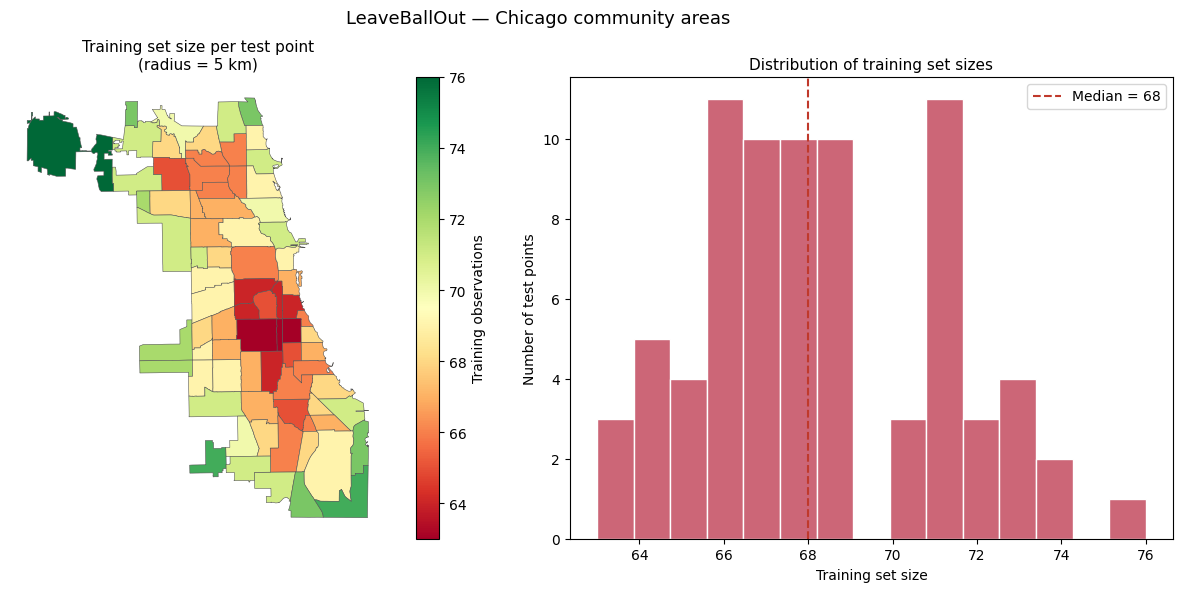

Training sizes: min=63, median=68, max=76


In [4]:
lbo_chi = LeaveBallOut(radius=RADIUS_CHI)

train_sizes = []
for train, test in lbo_chi.split(chicago):
    train_sizes.append(len(train))

chicago['lbo_train_n'] = train_sizes

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Map of training set size per test point
chicago.plot(
    column='lbo_train_n', cmap='RdYlGn',
    legend=True, legend_kwds={'label': 'Training observations'},
    ax=axes[0], edgecolor='#555', linewidth=0.4,
)
axes[0].set_title(
    f'Training set size per test point\n(radius = {RADIUS_CHI/1000:.0f} km)',
    fontsize=11,
)
axes[0].axis('off')

# Distribution
axes[1].hist(train_sizes, bins=15, color=colormaps.safe(0.15), edgecolor='white')
axes[1].axvline(numpy.median(train_sizes), color='#c0392b', lw=1.5, ls='--',
                label=f'Median = {numpy.median(train_sizes):.0f}')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('Number of test points')
axes[1].set_title('Distribution of training set sizes', fontsize=11)
axes[1].legend()

fig.suptitle('LeaveBallOut — Chicago community areas', fontsize=13)
fig.tight_layout()
plt.show()
print(f'Training sizes: min={min(train_sizes)}, median={numpy.median(train_sizes):.0f}, max={max(train_sizes)}')

## Large example — King County house sales (600 points)

With a point dataset the spatial leakage problem is sharper: nearby sales
share neighbourhood effects (school district, local amenities) that random
CV cannot separate from genuine model skill.

We use a stratified subsample of 600 sales (60 per log-price decile,
UTM 10N, metres) and compare `LeaveBallOut` against random leave-one-out
(i.e. standard LOO with no exclusion buffer).


In [5]:
gdf_full = geopandas.read_file(geodatasets.get_path('geoda.home_sales')).to_crs('EPSG:32610')
gdf_full['log_price'] = numpy.log(gdf_full['price'])
gdf_full['decile'] = (
    gdf_full['log_price'].rank(pct=True).multiply(10).clip(upper=9.99).astype(int)
)
idx = (
    gdf_full.groupby('decile')
    .apply(lambda g: g.sample(min(60, len(g)), random_state=42), include_groups=False)
    .index.get_level_values(1)
)
gdf = gdf_full.loc[idx].reset_index(drop=True)
print(f'n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} -- ${gdf.price.max():,.0f}')

n = 600 sales  |  price $84,000 -- $3,168,750


### Effect of buffer radius on training set size

Larger radii exclude more nearby sales, leaving fewer training points per
fold.  The plot shows the median and IQR of training set size across all
600 test points as a function of radius.


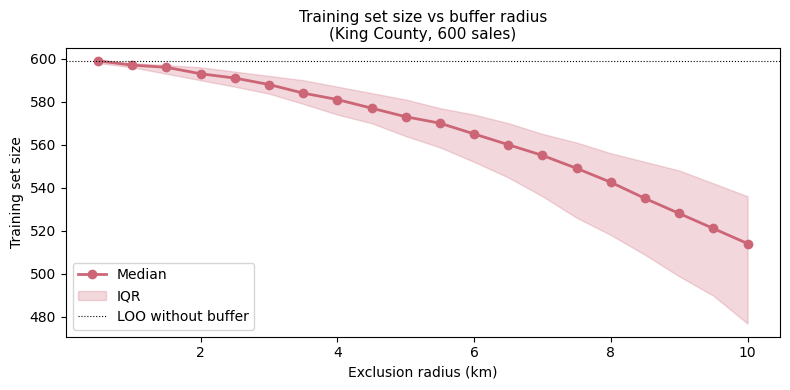

In [6]:
coords = numpy.column_stack([gdf.geometry.x, gdf.geometry.y])

radii_km = numpy.arange(0.5, 10.5, 0.5)
medians, q25s, q75s = [], [], []

for r_km in radii_km:
    sizes = []
    lbo = LeaveBallOut(radius=r_km * 1000)
    for train, test in lbo.split(gdf):
        sizes.append(len(train))
    medians.append(numpy.median(sizes))
    q25s.append(numpy.percentile(sizes, 25))
    q75s.append(numpy.percentile(sizes, 75))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(radii_km, medians, 'o-', color=colormaps.safe(0.15), lw=2, label='Median')
ax.fill_between(radii_km, q25s, q75s, alpha=0.25, color=colormaps.safe(0.15), label='IQR')
ax.set_xlabel('Exclusion radius (km)')
ax.set_ylabel('Training set size')
ax.set_title('Training set size vs buffer radius\n(King County, 600 sales)', fontsize=11)
ax.axhline(len(gdf) - 1, color='k', lw=0.8, ls=':', label='LOO without buffer')
ax.legend()
fig.tight_layout()
plt.show()

### Cross-validation comparison

We compare three CV strategies predicting log(price) from structural features
(sq ft, beds, baths, grade):

1. **LeaveBallOut (5 km)** — excludes nearby sales from training
2. **LOO without buffer** — standard leave-one-out, no spatial exclusion

With no buffer, the model can 'cheat' by memorising neighbourhood trends;
`LeaveBallOut` forces it to generalise across space.


In [7]:
RADIUS_M = 5_000
feat_cols = ['sqft_liv', 'bedrooms', 'bathrooms', 'grade']
y = numpy.log(gdf['price'].values)
X_feat = gdf[feat_cols].fillna(0).values

# LeaveBallOut CV
lbo = LeaveBallOut(radius=RADIUS_M)
lbo_preds = numpy.full(len(gdf), numpy.nan)
lbo_train_n = []
for train, test in lbo.split(gdf):
    if len(train) < 5:
        continue
    lr = LinearRegression().fit(X_feat[train], y[train])
    lbo_preds[test] = lr.predict(X_feat[test])
    lbo_train_n.append(len(train))

# Standard LOO (no buffer)
from sklearn.model_selection import LeaveOneOut
loo_preds = numpy.full(len(gdf), numpy.nan)
for train, test in LeaveOneOut().split(X_feat):
    lr = LinearRegression().fit(X_feat[train], y[train])
    loo_preds[test] = lr.predict(X_feat[test])

valid = ~numpy.isnan(lbo_preds)
lbo_rmse = root_mean_squared_error(y[valid], lbo_preds[valid])
loo_rmse = root_mean_squared_error(y, loo_preds)

lbo_resid = lbo_preds[valid] - y[valid]
loo_resid = loo_preds - y

print(f'LeaveBallOut (r={RADIUS_M/1000:.0f} km)  RMSE: {lbo_rmse:.4f}  (n={valid.sum()} predictions)')
print(f'LOO (no buffer)                RMSE: {loo_rmse:.4f}  (n={len(gdf)} predictions)')
print(f'Buffered exclusion adds {lbo_rmse - loo_rmse:+.4f} log-price RMSE -- spatial leakage effect')

LeaveBallOut (r=5 km)  RMSE: 0.3774  (n=600 predictions)
LOO (no buffer)                RMSE: 0.3636  (n=600 predictions)
Buffered exclusion adds +0.0137 log-price RMSE -- spatial leakage effect


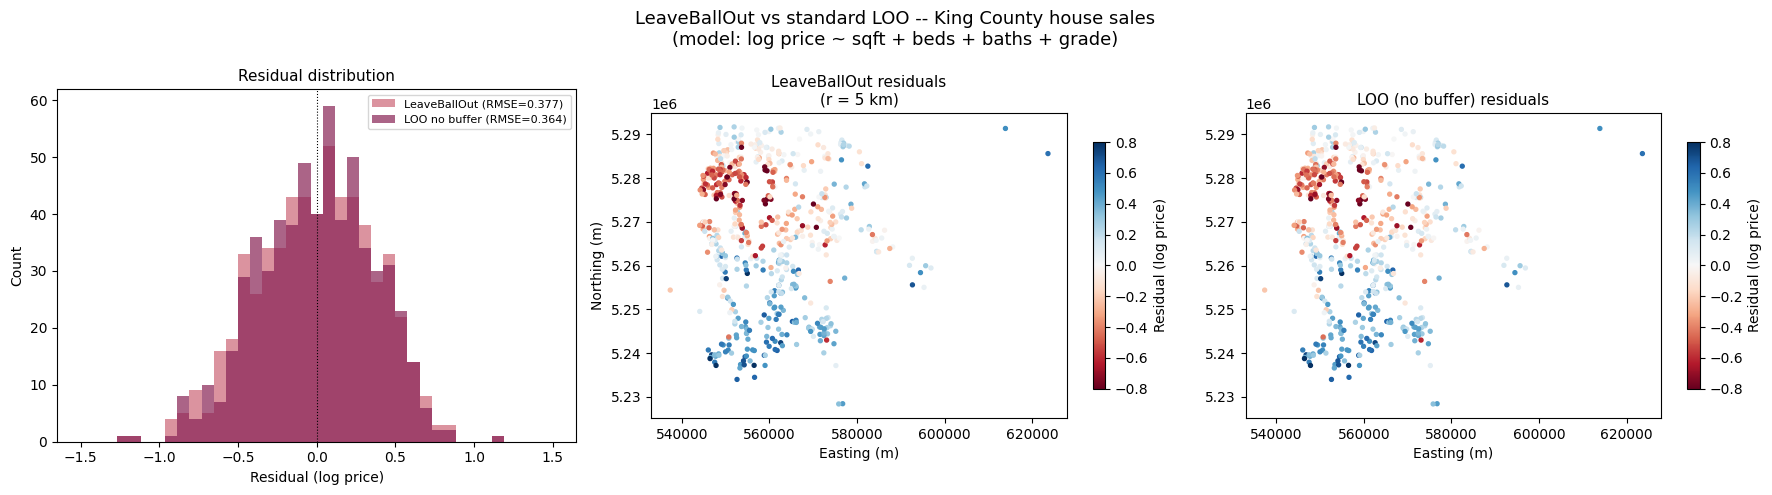

In [8]:
c_lbo  = colormaps.safe(0.15)
c_loo  = colormaps.safe(0.75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 -- residual distributions
ax = axes[0]
bins = numpy.linspace(-1.5, 1.5, 40)
ax.hist(lbo_resid, bins=bins, color=c_lbo, alpha=0.7, label=f'LeaveBallOut (RMSE={lbo_rmse:.3f})')
ax.hist(loo_resid, bins=bins, color=c_loo, alpha=0.7, label=f'LOO no buffer (RMSE={loo_rmse:.3f})')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('Residual (log price)')
ax.set_ylabel('Count')
ax.set_title('Residual distribution', fontsize=11)
ax.legend(fontsize=8)

# Panel 2 -- LBO residual map
ax = axes[1]
gdf_valid = gdf[valid].copy()
gdf_valid['resid'] = lbo_resid
gdf_valid.plot(
    column='resid', cmap='RdBu', vmin=-0.8, vmax=0.8,
    markersize=8, ax=ax, legend=True,
    legend_kwds={'label': 'Residual (log price)', 'shrink': 0.7},
)
ax.set_title(f'LeaveBallOut residuals\n(r = {RADIUS_M/1000:.0f} km)', fontsize=11)
ax.set_aspect('equal')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# Panel 3 -- LOO (no buffer) residual map
ax = axes[2]
gdf_loo = gdf.copy()
gdf_loo['resid'] = loo_resid
gdf_loo.plot(
    column='resid', cmap='RdBu', vmin=-0.8, vmax=0.8,
    markersize=8, ax=ax, legend=True,
    legend_kwds={'label': 'Residual (log price)', 'shrink': 0.7},
)
ax.set_title('LOO (no buffer) residuals', fontsize=11)
ax.set_aspect('equal')
ax.set_xlabel('Easting (m)')

fig.suptitle(
    'LeaveBallOut vs standard LOO -- King County house sales\n'
    '(model: log price ~ sqft + beds + baths + grade)',
    fontsize=13,
)
fig.tight_layout()
plt.show()